Apparent Competition

In [1]:
push!(LOAD_PATH, pwd()) # put current directory on path
using Revise
using UnPack
#include("ModelHelperFuns.jl")  # load the file
#using .ModelHelperFuns         # bring the module into scope
using CooperativeHuntingPkg
using Plots
default(
    guidefontsize=17,   # controls xlabel, ylabel, title font size
    tickfontsize=12,    # controls axis number labels
    legendfontsize=14,  # controls legend font
    linewidth=4,        # controls default line thickness
    grid = false,        # turns off grid in background
    fontfamily="Computer Modern" # font family that matches latex
)
using BifurcationKit, DifferentialEquations
# pgfplotsx()  # Set PGFPlotsX as the backend # this seems to not work on my computer, or on vscode.
using Measures # helps for adjusting location of axis labels
using LinearAlgebra
using ForwardDiff #this should be able to numerically find a jacobian
using LaTeXStrings

# saving with bif diagrams
bif_fig_path = "../../CH_manuscript/FIgures/BifurcationDiagrams/"


"../../CH_manuscript/FIgures/BifurcationDiagrams/"

# Functions and label dictionaries

In [ ]:
# these were supposed to load with my package but i guess it didn't work
ylabel_dic = Dict(
    :N1 => L"N_1"*", Scaled Big Prey\nDensity",
    :N2 => L"N_2"*", Scaled Small Prey\nDensity",
    :mean_x => "Mean Experienced\nGroup Size, "*L"\bar{x}",
    :p => L"Predator density, $p$",
    :Nsum => "Sum of Prey Densities,\n"*L"N_1 + N_2",
    :g1 => L"g(1)",
    :g2 => L"g(2)",
    :g3 => L"g(3)"
)

param_label_dic = Dict(
    :α1_of_1 => L"\alpha_1(1)",
    :α2_of_1 => L"\alpha_2(1)",
    :s1 => L"s_1",
    :s2 => L"s_2",
    :H1a => L"H_{1a}",
    :H2a => L"H_{2a}",
    :H2b => L"H_{2b}",
    :A1 => L"Relative Attack Rate of Big Prey, $A_1$",
    :A2 => L"A_2",
    :η2 => L"Growth of Small Prey, $\eta_2$",
    :β2 => L"\beta_2",
    :x_max => L"x_{max}",
    :Tg => "Relative Group Dynamics \nTimescale, "*L"T_g",
    :d => L"d",
    :scale => L"Benefit Ratio, $\beta_1/\beta_2$"
)
params_base = Dict(
    :α1_of_1 => 0.05,
    :α2_of_1 => 0.95,
    :s1 => 2.0,
    :s2 => 2.0,
    :H1a => 0.0,
    :H2a => 0.0,
    :H2b => 0.0,
    :A1 => 0.6,
    :A2 => 0.5,
    :η2 => 0.6,
    :β2 => 1.0,
    :α2_fun_type => "constant",
    :x_max => 10,
    :Tg => .01,
    :d => 100.0,
    :scale => 5.0
)
function get_apparent_comp_bothways(stable_coexist, gmat, params)
    num = length(stable_coexist[:N1])
    ∂N2_∂N1 = zeros(num)
    ∂N1_∂N2 = zeros(num)
    for i in 1:num
        # set up inputs
        N1 = stable_coexist[:N1][i]
        N2 = stable_coexist[:N2][i]
        g = gmat[i,:]
        params_use = deepcopy(params)
        params_use[:scale] = stable_coexist[:param][i]
        params_use = scale_parameters(params_use)
        @unpack scale, β1, β2, η1, η2, A1, A2, H1b, H2b = params_use
        # get jacobian
        #J= ForwardDiff.jacobian(u->fullsystem_scaled(u,params_use), [N1,N2,g...])
        J = Jacobian(N1,N2,g,params_use)
        ∂N2_∂N1[i] = get_∂N2_∂N1(J)
        ∂N1_∂N2[i] = get_∂N1_∂N2(J)
    end
    return ∂N2_∂N1, ∂N1_∂N2
end

function get_stable_equilibria( params; 
    lens = (@optic _.scale), p_min = 1.01, p_max = 8.0
    )

    @unpack x_max = params
    u0 = fill(0.1, x_max+2)
    p_nt = NamedTuple(scale_parameters(params))
    br_list = do_base_continuations(
        p_nt, x_max;
        lens = lens, p_min = p_min, p_max = p_max
        );

    br_coexist = br_list[:coexist]
    filtered_coexist = extract_branch_matrix(br_coexist, params[:x_max])
    indices = findall(xvec -> xvec==1.0, filtered_coexist.stable)

    stable_coexist = Dict()
    for (key, value) in pairs(filtered_coexist)
        stable_coexist[key] = value[indices]
    end

    # store g's in a matrix
    gmat = fill(1.0, (length(stable_coexist[:N1]), params[:x_max]))
    for i in 1:x_max
        gmat[:,i] = stable_coexist[Symbol("g$i")]
    end
    return stable_coexist, gmat
end
function plot_distribution_heatmap(gmat, stable_coexist, x_max)
    # prob_x_mat: matrix (rows = param values, cols = x values)
    prob_x_mat = get_prob_in_x(gmat, stable_coexist[:P], x_max);
    # stable_coexist[:param]: vector for x-axis
    # xvec: vector for y-axis (e.g., 1:x_max)
    xvec = 1:x_max
    plt_heat = heatmap(
        stable_coexist[:param], 
        xvec, 
        prob_x_mat', 
        c = cgrad([:white, :black], 256),
        clim = (0, maximum(prob_x_mat) + .01),          # scale from 0 (white) to 1 (black)
        xlabel = param_label_dic[:scale], 
        ylabel = L"Group size, $x$",
        right_margin = 15mm,
        #colorbar_titlefontrotation = 180,
        yflip = false            # optional: flip y-axis if you want black at the top
    )
    plot!(
        stable_coexist[:param],
        stable_coexist[:mean_x],
        label = "Mean Experienced",
        color = :yellow,
        linewidth=4
    )
    annotate!(
        (1.2, 0.5),
        text(L"\textrm{Prob.\ in\ group\ size}\ x", 16, :center, rotation = -90),
        
    )
    return plt_heat
end

function find_mangel_clark(N1, N2, params)
    # Mangel and Clark predicted that groups should grow until W(x^*) = W(1)
    # Simplest way: iterate and stop when W(x) < W(1), then return x - 1
    @unpack x_max = params
    W_of_1 = fun_W(1, N1, N2, params)
    for x in 2:x_max
        W_of_x = fun_W(x, N1, N2, params)
        if W_of_x < W_of_1
            return x - 1
        end
    end
    return x_max  # If reach x_max
end

function plot_mc_line(plt, stable_coexist, params_base)
    x_list_mangel_clark = []
    params = deepcopy(params_base)
    for (i,param) in enumerate(stable_coexist[:param])
        # get parameter value and prey values
        N1 = stable_coexist[:N1][i]
        N2 = stable_coexist[:N2][i]
        params[:scale] = param

        # update parameters dictionary using scaling laws
        params = scale_parameters(params)

        # get mangel and clark prediction
        x_mc = find_mangel_clark(N1, N2, params)
        push!(x_list_mangel_clark, x_mc)
    end
    # plot
    plot!(stable_coexist[:param], x_list_mangel_clark, 
    color = :limegreen,
    label="Clark & Mangel")
end

function plot_opt_line(plt, stable_coexist, params_base)
    """
    Plots the group size that maximizes fitness atht eequilibrium
    """
    x_list = []
    params = deepcopy(params_base)
    for (i,param) in enumerate(stable_coexist[:param])
        # get parameter value and prey values
        N1 = stable_coexist[:N1][i]
        N2 = stable_coexist[:N2][i]
        params[:scale] = param

        # update parameters dictionary using scaling laws
        params = scale_parameters(params)

        # get mangel and clark prediction
        W = fun_W(1:params_base[:x_max], N1, N2, params)
        x_opt = findmax(W)[2]
        push!(x_list, x_opt)
    end
    plot!(
        stable_coexist[:param], x_list, color = :magenta,
        linewidth=5,
        label = "Optimal"
        )

end

# Type I, varying scale

## Get stable equilibria

In [3]:
params_t1 = deepcopy(params_base)
params_t1[:x_max] = 10
stable_coexist_t1, gmat_t1 = get_stable_equilibria(params_t1)

┌ Error: Failure to converge with given tolerance = 1.0e-12.
│ Step = 309
│ You can decrease the tolerance or pass a different norm using the argument `normC`.
│ We reached the smallest value [dsmin] valid for ds, namely 0.0001.
│ Stopping continuation at continuation step 309.
└ @ BifurcationKit /Users/taliaborofsky/.julia/packages/BifurcationKit/nhoqA/src/continuation/Contbase.jl:67


(Dict{Any, Any}(:g6 => [0.00666071695692858, 0.004745673065456343, 0.0033757517156455495, 0.00240007847284696, 0.0017070471960128957, 0.001215449026716322, 0.0008668558375950547, 0.000619553529251806, 0.0004439156826386317, 0.00031897157054400975  …  4.060447536607813e-10, 4.054190811722416e-10, 4.047943032162752e-10, 4.041704171995875e-10, 4.0354742058218647e-10, 4.029253108762269e-10, 4.023040856448745e-10, 4.0168374250098566e-10, 4.0106427910592245e-10, 4.009724974818163e-10], :g5 => [0.03624638685383895, 0.0303185475667105, 0.02527675789958768, 0.021025136499340343, 0.017462450683037842, 0.0144909559675379, 0.012020959046115295, 0.009972773176021021, 0.008277138621899422, 0.006874786998449806  …  2.3666210015572703e-7, 2.3620168661235213e-7, 2.3574252166350426e-7, 2.3528459834935964e-7, 2.3482790979118026e-7, 2.3437244919002016e-7, 2.339182098254495e-7, 2.334651850542296e-7, 2.3301336830904157e-7, 2.3294647365780324e-7], :g3 => [0.2724677420014103, 0.2767830771001032, 0.28012192934

In [4]:
∂N2_∂N1_t1, ∂N1_∂N2_t1 = get_apparent_comp_bothways(
    stable_coexist_t1, gmat_t1, params_t1
    )

([-1.4504416279120536, -1.4074658503596342, -1.3772456881836328, -1.3561363899621746, -1.3417703585433638, -1.332539722426087, -1.3273118301670563, -1.325263762866847, -1.3257815174430003, -1.3283961706682095  …  -3.9493787017654527, -3.9512179102399734, -3.953044835630045, -3.9548595248499208, -3.9566620246367608, -3.9584523816057553, -3.960230642250125, -3.9619968529258762, -3.963751059841885, -3.9640101611638903], [-0.8135296987207561, -0.8301019642029914, -0.8424938151068623, -0.8515936882645132, -0.8580668188615571, -0.8624220999148842, -0.8650559407615006, -0.866281959469399, -0.8663516254336772, -0.8654689376731077  …  -0.32891066392277846, -0.3286924545658652, -0.3284753523589917, -0.32825935091611597, -0.3280444438992314, -0.3278306250157946, -0.32761788802137387, -0.32740622671503333, -0.32719563494240944, -0.3271644982781888])

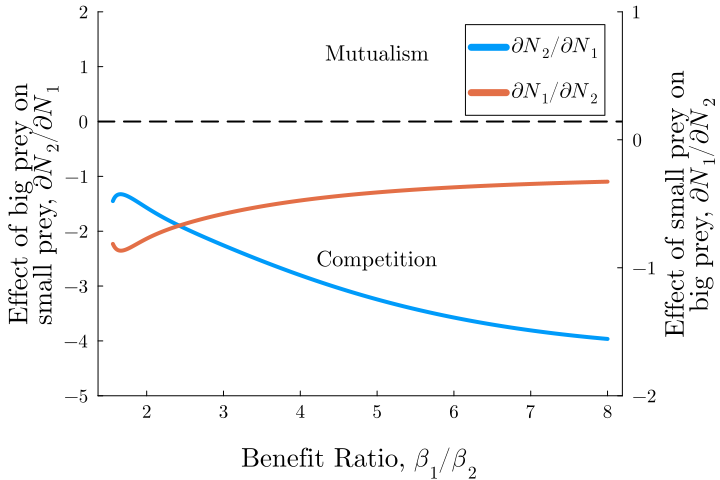

In [5]:
plt = plot(
    stable_coexist_t1[:param], # i looked at the values and 207 is about where there's a change
    ∂N2_∂N1_t1, 
    label = L"\partial N_2/\partial N_1", 
    color = 1, 
    ylabel = "Effect of big prey on\n"*L"small prey, $\partial N_2/\partial N_1$",
    xlab = "\n"*param_label_dic[:scale],
    ylims = [-5,2]
    )
annotate!((5.0,1.25,"Mutualism"))
annotate!((5.0,-2.5,"Competition"))
plot!([],[], color = :white, label = " ")
plot!([],[], color = 2,label = L"\partial N_1/\partial N_2") # need this in order to show both labels
plot!(
    twinx(), stable_coexist_t1[:param], ∂N1_∂N2_t1, 
    label = nothing,#[L"N_2 \to N_1"], 
    ylabel = "Effect of small prey on\n"*L"big prey, $\partial N_1/\partial N_2$",
    color = 2,
    ylims = [-2,1])
hline!([0], color = :black, linestyle = :dash, linewidth = 2, label = nothing)
plot!(
    legend = :topright,
    bottommargin = 3mm, # prevents xlab from being cutoff
    right_margin=4mm,
    left_margin=4mm,
    size = (720,480)
)

savefig(plt, bif_fig_path*"apparent_comp_t1_scale.pdf")
plt


## Plot Distribution

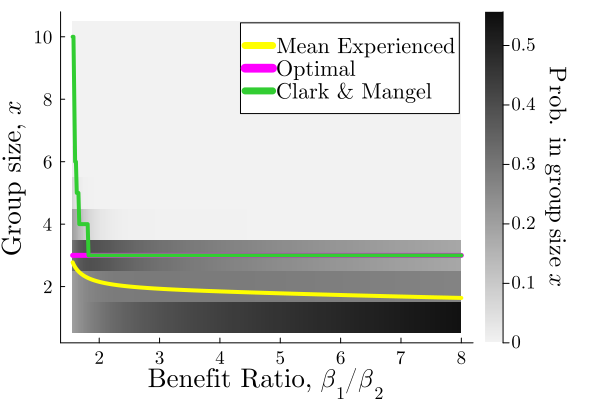

In [19]:
x_max = params_t1[:x_max]
plt = plot_distribution_heatmap(gmat_t1, stable_coexist_t1, x_max)
plot_opt_line(plt, stable_coexist_t1, params_t1)
plot_mc_line(plt, stable_coexist_t1, params_t1)
savefig(plt, bif_fig_path*"distribution_t1_scale.pdf")
plt


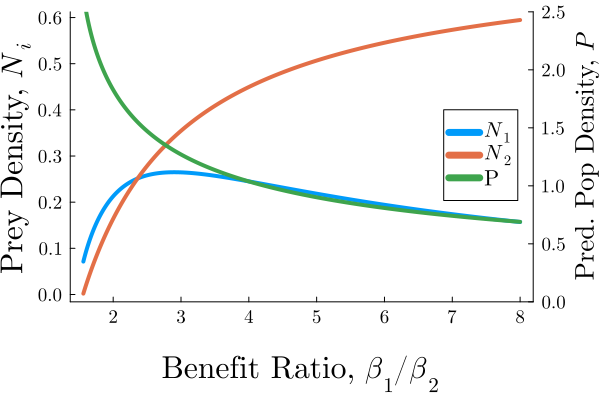

In [11]:
#size_explanatory_plots = (600, 133)
plt_N = plot(
    stable_coexist_t1[:param], 
    stable_coexist_t1[:N1], 
    label = L"N_1",
    linewidth=4
    )
plot!(
    stable_coexist_t1[:param], 
    stable_coexist_t1[:N2], 
    label = L"N_2",
    linewidth=4
    )
plot!([],[],color=3, linewidth=4, label = "P")
plot!(ylab = L"Prey Density, $N_i$",
    xlab = "\n"*param_label_dic[:scale],
    bottommargin = 5mm,
    guidefontsize=20,
    legend = :right
    )#ylab = "Scaled Prey Density\nat Equilibrium"
plot!(
    twinx(), stable_coexist_t1[:param], stable_coexist_t1[:P], 
    label = nothing,#[L"N_2 \to N_1"], 
    ylabel = L"Pred. Pop Density, $P$",
    color = 3,
    linewidth=4,
    ylims = [0,2.5])
savefig(plt_N, bif_fig_path*"stable_N_t1_scale.pdf")
plt_N


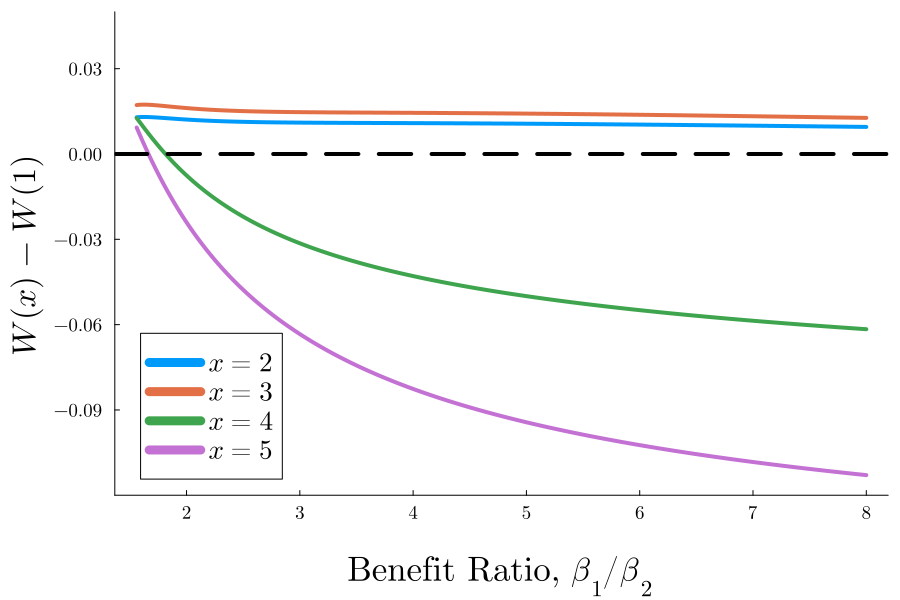

In [12]:
# explanatory figures
# get W mat
num = length(stable_coexist_t1[:N1])
xvec = 1:x_max
Wmat = zeros(num,x_max)
for i in 1:num
    # set up inputs
    N1 = stable_coexist_t1[:N1][i]
    N2 = stable_coexist_t1[:N2][i]
    params_use = deepcopy(params_t1)
    params_use[:scale] = stable_coexist_t1[:param][i]
    params_use = scale_parameters(params_use)
    
    Wmat[i,:] = fun_W(xvec,N1,N2,params_use)
end
# plot heatmap of W
# stable_coexist_t1[:param]: vector for x-axis
# xvec: vector for y-axis (e.g., 1:x_max)
xvec = 1:x_max
plt = plot(
    xlab = "\n"*param_label_dic[:scale],
    ylab = L"W(x) - W(1)",
    bottommargin=5mm)
for x in 2:5
    plot!(stable_coexist_t1[:param], Wmat[:,x] .- Wmat[:,1], label = L"x=%$x",
    guidefontsize=22, left_margin = 5mm, legendfontsize=18,
    linewidth=4,
    )
end
plot!(ylim = [-0.12,0.05])
hline!([0],linestyle=:dash, color = :black, label = nothing,size=(600,400).*1.5)
savefig(plt, bif_fig_path*"W_t1_scale.pdf")
plt



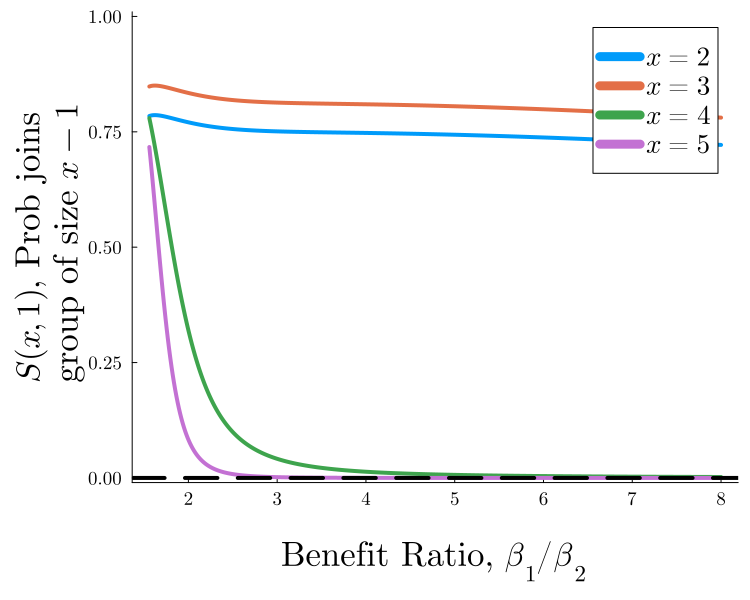

In [13]:
# explanatory figures
# get W mat
num = length(stable_coexist_t1[:N1])
xvec = 1:x_max
Wmat = zeros(num,x_max)
for i in 1:num
    # set up inputs
    N1 = stable_coexist_t1[:N1][i]
    N2 = stable_coexist_t1[:N2][i]
    params_use = deepcopy(params_t1)
    params_use[:scale] = stable_coexist_t1[:param][i]
    params_use = scale_parameters(params_use)
    
    Wmat[i,:] = fun_W(xvec,N1,N2,params_use)
end
# plot heatmap of W
# stable_coexist[:param]: vector for x-axis
# xvec: vector for y-axis (e.g., 1:x_max)
xvec = 1:x_max
plt = plot(
    xlab = "\n"*param_label_dic[:scale],
    ylab = L"$S(x,1)$, Prob joins"*"\n group of"* L" size $x-1$",
    bottommargin=5mm)
for x in 2:5 #xvec[2:end]
    plot!(
        stable_coexist_t1[:param], 
        1 ./(1 .+ exp.(-params_t1[:d] .* (Wmat[:,x] .- Wmat[:,1]))), 
        label = L"x=%$x",
    guidefontsize=22, left_margin = 5mm, legendfontsize=18,
    linewidth=4,
    )
end
plot!(ylim = [-0.01,1.01])
hline!([0],linestyle=:dash, color = :black, label = nothing,size=(500,400).*1.5)
#savefig(plt, bif_fig_path*"W_t1_scale.pdf")
plt



## Scale vs eta2

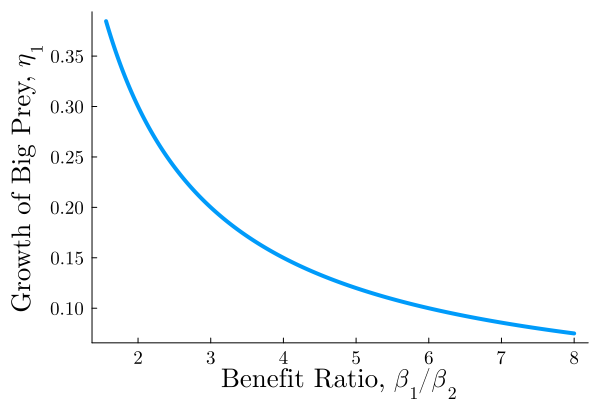

In [14]:
scale = stable_coexist_t1[:param]
η2 = params_t1[:η2]
η1 = η2 ./ scale

plot(
    scale, η1, label = nothing,
    ylab = L"Growth of Big Prey, $\eta_1$",
    xlab = param_label_dic[:scale],
    left_margin = 5mm)

- compare this to group size without population dynamics
    to isolate the population dynamics is reducing group sizes
- need to S(x,1) curves
- even though most predators are singletons, there aren't many predators, which reduces the rate of group formation from predators running into each other

# Type II, varying scale

## Get Stable Equilibria

In [6]:
params_base = Dict(
    :α1_of_1 => 0.05,
    :α2_of_1 => 0.95,
    :s1 => 2.0,
    :s2 => 2.0,
    :H1a => 0.0,
    :H2a => 0.0,
    :H2b => 0.0,
    :A1 => 0.6,
    :A2 => 0.5,
    :η2 => 0.6,
    :β2 => 1.0,
    :α2_fun_type => "constant",
    :x_max => 10,
    :Tg => .01,
    :d => 100.0,
    :scale => 5.0
)
# type II, vary scale
params_t2 = deepcopy(params_base)
params_t2[:H1a] = params_t2[:H2a] = 0.0
params_t2[:H2b] = 1.0
stable_coexist_t2, gmat_t2 = get_stable_equilibria(params_t2)
∂N2_∂N1_t2, ∂N1_∂N2_t2 = get_apparent_comp_bothways(stable_coexist_t2, gmat_t2, params_t2)

([-1.4315956442359221, -1.3851892755653912, -1.3510461141422445, -1.3256095167376813, -1.3065620706375227, -1.292327707735325, -1.2817964943887268, -1.274163859686291, -1.2688322870290694, -1.2653488490804776  …  -3.195948867394979, -3.1725143687400745, -3.149566464391012, -3.127092920704187, -3.1050818605455763, -3.0835217500419185, -3.0624013858867416, -3.041709883249978, -3.0214366641931436, -3.0182700653725636], [-0.8245648713137291, -0.8433337270904514, -0.8581534046074948, -0.8698716119140524, -0.8791217525819428, -0.8863865072588182, -0.8920397768439775, -0.8963752167369639, -0.8996261637127927, -0.9019798682241069  …  -0.37221947330061217, -0.37317686982973375, -0.3741201194165984, -0.37504919654388646, -0.3759640822662869, -0.3768647641642389, -0.3777512362925574, -0.37862349912286236, -0.3794815594812513, -0.37961587758966087])

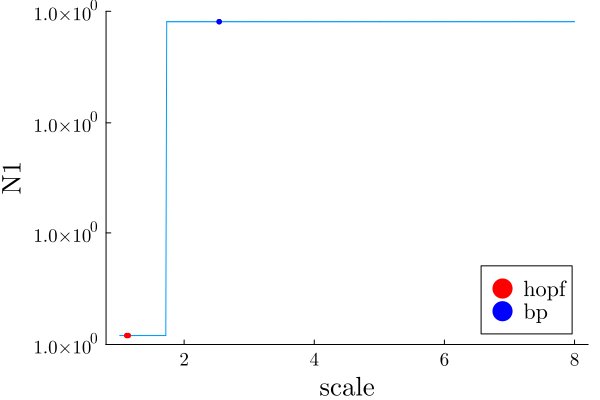

GKS: Possible loss of precision in routine SET_WINDOW


In [45]:
plot(br_list[:N2_extinct])

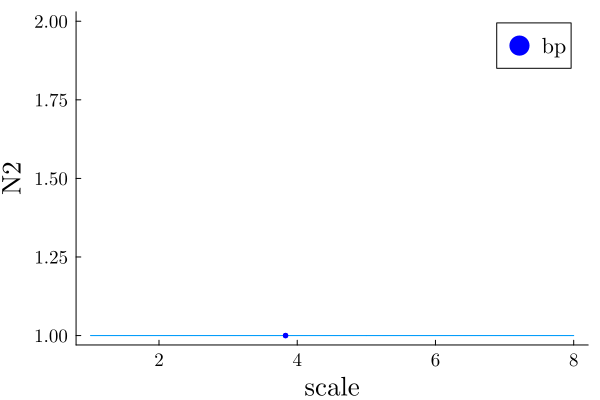

In [47]:
plot(br_list[:N1_extinct], vars = (:param, :N2))

In [56]:
sp

SpecialPoint{Float64, @NamedTuple{N1::Float64, N2::Float64, g1::Float64, g2::Float64, g3::Float64, g4::Float64, g5::Float64, g6::Float64, g7::Float64, g8::Float64, g9::Float64, g10::Float64, P::Float64, mean_x::Float64}, Vector{Float64}, Vector{Float64}}
  type: Symbol bp
  idx: Int64 110
  param: Float64 2.5385668621197492
  norm: Float64 1.0000000000000469
  printsol: @NamedTuple{N1::Float64, N2::Float64, g1::Float64, g2::Float64, g3::Float64, g4::Float64, g5::Float64, g6::Float64, g7::Float64, g8::Float64, g9::Float64, g10::Float64, P::Float64, mean_x::Float64}
  x: Array{Float64}((12,)) [1.0000000000000469, 0.0, 4.700398782459123e-14, -5.2589649674197145e-15, -3.2921704858150076e-15, -3.595846139993713e-15, -2.4630670564627317e-16, -9.029071513651301e-15, 1.4059190805783271e-14, -2.7502013986762624e-14, 3.0215004202362045e-14, -2.076559129823404e-14]
  τ: BorderedArray{Vector{Float64}, Float64}
  ind_ev: Int64 2
  step: Int64 109
  status: Symbol converged
  δ: Tuple{Int64, Int64}


In [7]:
p_nt = scale_parameters(NamedTuple(params_t2))
@unpack x_max = p_nt
br_list = diagram_2_recursion(p_nt; 
        systemfunction = fullsystem_scaled, 
        system_type = nothing,
        paramkey = :scale, 
        lens = (@optic _.scale), 
        p_min = 1.01, p_max = 8.0, 
        dsmax = 0.01)

did base continuations


┌ Error: Failure to converge with given tolerance = 1.0e-12.
│ Step = 49
│ You can decrease the tolerance or pass a different norm using the argument `normC`.
│ We reached the smallest value [dsmin] valid for ds, namely 0.0001.
│ Stopping continuation at continuation step 49.
└ @ BifurcationKit /Users/taliaborofsky/.julia/packages/BifurcationKit/nhoqA/src/continuation/Contbase.jl:67


((coexist =  ┌─ Curve type: EquilibriumCont
 ├─ Number of points: 557
 ├─ Type of vectors: Vector{Float64}
 ├─ Parameter scale starts at 1.01, ends at 8.0
 ├─ Algo: PALC
 └─ Special points:

- #  1, endpoint at scale ≈ +1.01000000,                                                                     step =   0
- #  2,     hopf at scale ≈ +1.13643756 ∈ (+1.13643756, +1.13643765), |δp|=8e-08, [converged], δ = ( 2,  2), step =  27
- #  3,     hopf at scale ≈ +1.22099797 ∈ (+1.22099797, +1.22099799), |δp|=2e-08, [converged], δ = (-2, -2), step =  42
- #  4,       bp at scale ≈ +1.46817888 ∈ (+1.46817888, +1.46817888), |δp|=1e-09, [converged], δ = ( 1,  0), step =  88
- #  5,       bp at scale ≈ +1.55660952 ∈ (+1.55660952, +1.55661114), |δp|=2e-06, [converged], δ = (-1,  0), step =  96
- #  6, endpoint at scale ≈ +8.00000000,                                                                     step = 556
, predator_extinct =  ┌─ Curve type: EquilibriumCont
 ├─ Number of points: 498
 ├─ Type o

In [83]:
base_branches, extra_branches = br_list

((coexist =  ┌─ Curve type: EquilibriumCont
 ├─ Number of points: 557
 ├─ Type of vectors: Vector{Float64}
 ├─ Parameter scale starts at 1.01, ends at 8.0
 ├─ Algo: PALC
 └─ Special points:

- #  1, endpoint at scale ≈ +1.01000000,                                                                     step =   0
- #  2,     hopf at scale ≈ +1.13643757 ∈ (+1.13643757, +1.13643765), |δp|=8e-08, [converged], δ = ( 2,  2), step =  27
- #  3,     hopf at scale ≈ +1.22099797 ∈ (+1.22099797, +1.22099799), |δp|=2e-08, [converged], δ = (-2, -2), step =  42
- #  4,       bp at scale ≈ +1.46817888 ∈ (+1.46817888, +1.46817888), |δp|=1e-09, [converged], δ = ( 1,  0), step =  88
- #  5,       bp at scale ≈ +1.55660952 ∈ (+1.55660952, +1.55661114), |δp|=2e-06, [converged], δ = (-1,  0), step =  96
- #  6, endpoint at scale ≈ +8.00000000,                                                                     step = 556
, predator_extinct =  ┌─ Curve type: EquilibriumCont
 ├─ Number of points: 498
 ├─ Type o

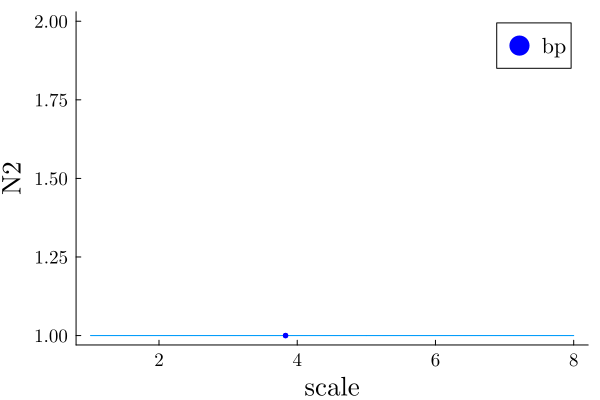

In [87]:
plot(base_branches[:N1_extinct], vars = (:param, :N2))

## Plot Apparent Competition

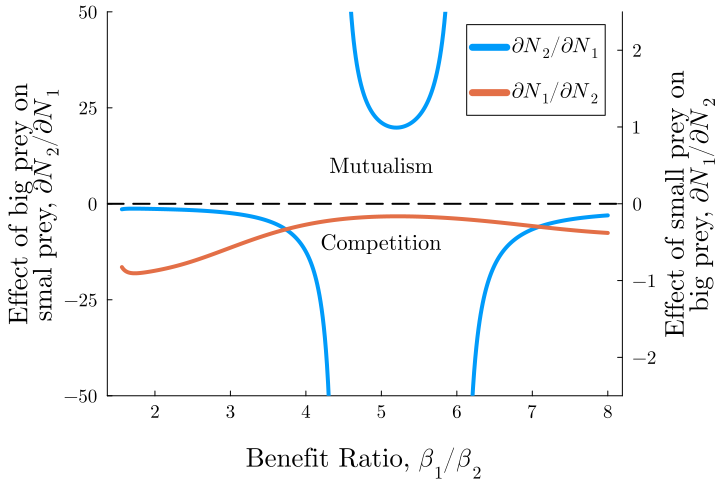

In [8]:
ix_end_below_1 = findfirst( ∂N2_∂N1_t2.> 0)
ix_end_above = findlast( ∂N2_∂N1_t2.> 0)
plt = plot(
    stable_coexist_t2[:param][1:ix_end_below_1 - 1], # i looked at the values and 207 is about where there's a change
    ∂N2_∂N1_t2[1:ix_end_below_1 - 1], 
    label = L"\partial N_2/\partial N_1", 
    color = 1, 
    ylabel = "Effect of big prey on\n"*"smal prey, "*L"\partial N_2/\partial N_1",
    xlab = "\n"*param_label_dic[:scale],
    ylims = [-50,50]
    )
annotate!((5.0,10,"Mutualism"))
annotate!((5.0,-10,"Competition"))
plot!(stable_coexist_t2[:param][ix_end_below_1:ix_end_above], ∂N2_∂N1_t2[ix_end_below_1:ix_end_above], 
    label = nothing, color = 1)
plot!(stable_coexist_t2[:param][ix_end_above+1:end], ∂N2_∂N1_t2[ix_end_above+1:end], 
    label = nothing, color = 1)
plot!([], [], color = :white, label = " ")
plot!([],[], color = 2,label = L"\partial N_1/\partial N_2")
plot!(
    twinx(), stable_coexist_t2[:param], ∂N1_∂N2_t2, 
    label = nothing,#[L"N_2 \to N_1"], 
    ylabel = "Effect of small prey on\n"*L"big prey, $\partial N_1/\partial N_2$",
    color = 2,
    ylims = [-2.5,2.5])
hline!([0], color = :black, linestyle = :dash, linewidth = 2, label = nothing)
plot!(
    legend = :topright,
    rightmargin=4mm,
    leftmargin=4mm,
    bottommargin = 3mm, # prevents xlab from being cutoff
    size=(720,480)
)

savefig(plt, bif_fig_path*"apparent_comp_t2_scale.pdf")
plt


## Explanatory figures: distribution, p, N1, N2, W

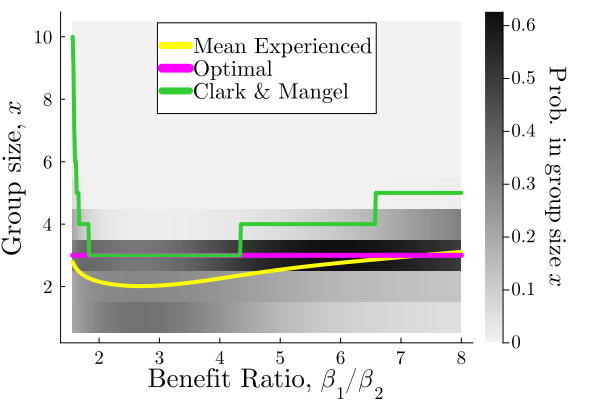

In [20]:
plt_heat = plot_distribution_heatmap(gmat_t2, stable_coexist_t2, params_t2[:x_max])
plot_opt_line(plt, stable_coexist_t2, params_t2)
plot_mc_line(plt, stable_coexist_t2, params_t2)
plot!(legend=:top)
savefig(plt_heat, bif_fig_path*"distribution_t2_scale.pdf")
plt_heat


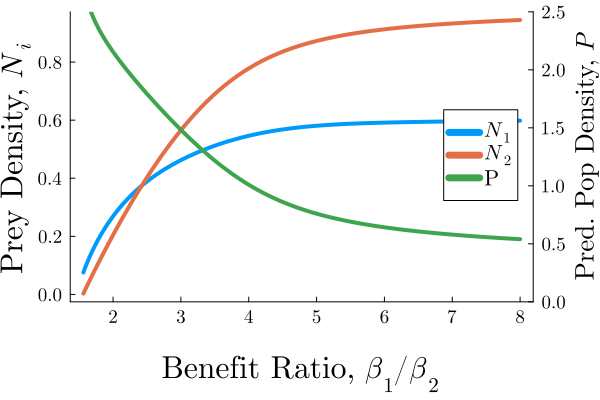

In [18]:
#size_explanatory_plots = (600, 133)
plt_N = plot(
    stable_coexist_t2[:param], 
    stable_coexist_t2[:N1], 
    label = L"N_1",
    linewidth=4
    )
plot!(
    stable_coexist_t2[:param], 
    stable_coexist_t2[:N2], 
    label = L"N_2",
    linewidth=4
    )
plot!([],[],color=3, linewidth=4, label = "P")
plot!(ylab = L"Prey Density, $N_i$",
    xlab = "\n"*param_label_dic[:scale],
    bottommargin = 5mm,
    guidefontsize=20,
    legend = :right
    )#ylab = "Scaled Prey Density\nat Equilibrium"
plot!(
    twinx(), stable_coexist_t2[:param], stable_coexist_t2[:P], 
    label = nothing,#[L"N_2 \to N_1"], 
    ylabel = L"Pred. Pop Density, $P$",
    color = 3,
    linewidth=4,
    ylims = [0,2.5])
savefig(plt_N, bif_fig_path*"stable_N_t2_scale.pdf")
plt_N


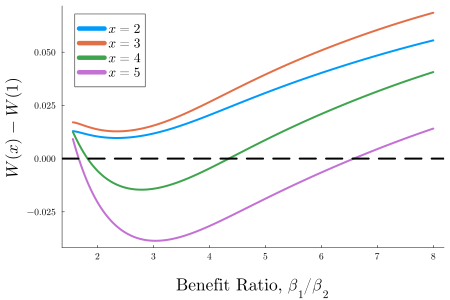

In [19]:
# explanatory figures
# get W mat
num = length(stable_coexist_t2[:N1])
xvec = 1:x_max
Wmat = zeros(num,x_max)
for i in 1:num
    # set up inputs
    N1 = stable_coexist_t2[:N1][i]
    N2 = stable_coexist_t2[:N2][i]
    params_use = deepcopy(params_t2)
    params_use[:scale] = stable_coexist_t2[:param][i]
    params_use = scale_parameters(params_use)
    
    Wmat[i,:] = fun_W(xvec,N1,N2,params_use)
end
# plot heatmap of W
# stable_coexist_t2[:param]: vector for x-axis
# xvec: vector for y-axis (e.g., 1:x_max)
xvec = 1:x_max
plt = plot(
    xlab = "\n"*param_label_dic[:scale],
    ylab = L"W(x) - W(1)",
    bottommargin=5mm)
for x in 2:5 #xvec[2:end]
    plot!(stable_coexist_t2[:param], Wmat[:,x] .- Wmat[:,1], label = L"x=%$x",
    guidefontsize=22, left_margin = 5mm, legendfontsize=18,
    linewidth=4,
    )
end
hline!([0],linestyle=:dash, color = :black, label = nothing,size=(600,400).*1.5)
savefig(plt, bif_fig_path*"W_t2_scale.pdf")
plt
plot!(dpi = 50)



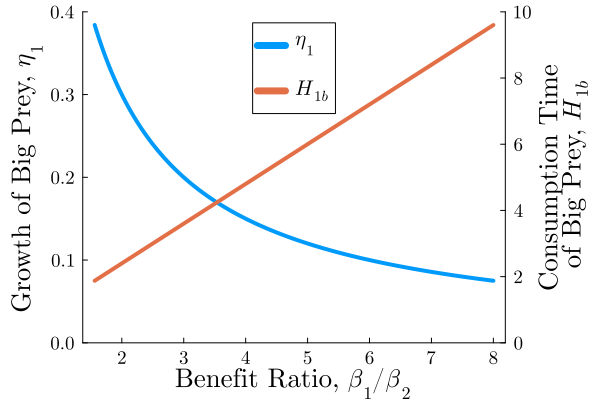

In [20]:
scale = stable_coexist_t2[:param]
@unpack η2, H2b, A1, A2 = params_t2
H1b = scale .* A1 * H2b / A2
η1 = η2 ./ scale

plt = plot(
    scale, η1, label = L"~\eta_1", 
    linewidth=4,
    ylab = L"Growth of Big Prey, $\eta_1$",
    xlab = param_label_dic[:scale],
    left_margin = 5mm,
    legend=:top,
    ylim = (0,0.4),
)
plot!([],[],color=:white, label = " ")
plot!([],[],linewidth=4,color=2,label=L"~H_{1b}")

plot!(twinx(),
    scale, H1b, label = nothing, linewidth=4,color=2,
    ylabel = "Consumption Time\n of Big Prey, "*L"H_{1b}",
    ylim = (0,10),
    right_margin=5mm
    )
savefig(plt, bif_fig_path*"params_t2_scale.pdf")
plt


# Try for other s values???

In [9]:
params_base = Dict(
    :α1_of_1 => 0.05,
    :α2_of_1 => 0.95,
    :s1 => 2.5,
    :s2 => 2.0,
    :H1a => 0.0,
    :H2a => 0.0,
    :H2b => 0.0,
    :A1 => 0.6,
    :A2 => 0.5,
    :η2 => 0.6,
    :β2 => 1.0,
    :α2_fun_type => "constant",
    :x_max => 10,
    :Tg => .01,
    :d => 100.0,
    :scale => 5.0
)
# type II, vary scale
params_t2 = deepcopy(params_base)
params_t2[:H1a] = params_t2[:H2a] = 0.0
params_t2[:H2b] = 1.0
stable_coexist_t2, gmat_t2 = get_stable_equilibria(params_t2)
∂N2_∂N1_t2, ∂N1_∂N2_t2 = get_apparent_comp_bothways(stable_coexist_t2, gmat_t2, params_t2)

([-1.8933896720327898, -1.85081768336321, -1.8196643962315981, -1.7968483561666326, -1.780267920065704, -1.768439731711845, -1.7602866610321735, -1.7550077087612224, -1.7519951103748581, -1.7507797719838267  …  0.8462534804340904, 0.8481245820102767, 0.8500149833175135, 0.8519246739541495, 0.8538536451547292, 0.8558018897690374, 0.8577694022370785, 0.8597561785564709, 0.8617622162668195, 0.8621121132600593], [-0.7500986968994953, -0.7638576031206545, -0.7753354331647788, -0.7850217922037018, -0.7932887258849897, -0.8004229316664695, -0.8066479391574274, -0.8121397464513314, -0.8170380717942756, -0.8214545961676386  …  -0.1971336146177378, -0.19789005731948803, -0.19864363393303117, -0.19939428152314878, -0.2001419387535065, -0.2008865458699613, -0.20162804468140821, -0.2023663785436247, -0.2031014923405939, -0.20322866240291748])

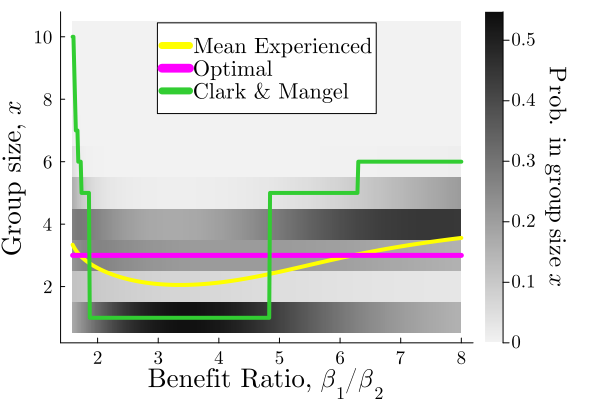

In [11]:
ix_end_below_1 = findfirst( ∂N2_∂N1_t2.> 0)
#ix_end_above = findlast( ∂N2_∂N1_t2.> 0)
plt = plot(
    stable_coexist_t2[:param][1:ix_end_below_1 - 1], # i looked at the values and 207 is about where there's a change
    ∂N2_∂N1_t2[1:ix_end_below_1 - 1], 
    label = L"\partial N_2/\partial N_1", 
    color = 1, 
    ylabel = "Effect of big prey on\n"*"smal prey, "*L"\partial N_2/\partial N_1",
    xlab = "\n"*param_label_dic[:scale],
    ylims = [-50,50]
    )
annotate!((5.5,10,"Mutualism"))
annotate!((5.5,-10,"Competition"))
plot!(stable_coexist_t2[:param][ix_end_below_1:end], ∂N2_∂N1_t2[ix_end_below_1:end], 
    label = nothing, color = 1)

plot!([], [], color = :white, label = " ")
plot!([],[], color = 2,label = L"\partial N_1/\partial N_2")
plot!(
    twinx(), stable_coexist_t2[:param], ∂N1_∂N2_t2, 
    label = nothing,#[L"N_2 \to N_1"], 
    ylabel = "Effect of small prey on\n"*L"big prey, $\partial N_1/\partial N_2$",
    color = 2,
    ylims = [-2.5,2.5])
hline!([0], color = :black, linestyle = :dash, linewidth = 2, label = nothing)
plot!(
    legend = :topright,
    rightmargin=4mm,
    leftmargin=4mm,
    bottommargin = 3mm, # prevents xlab from being cutoff
    size=(720,480)
)

#savefig(plt, bif_fig_path*"apparent_comp_t2_scale.pdf")
plt

plt_heat = plot_distribution_heatmap(gmat_t2, stable_coexist_t2, params_t2[:x_max])
plot_opt_line(plt, stable_coexist_t2, params_t2)
plot_mc_line(plt, stable_coexist_t2, params_t2)
plot!(legend=:top)
#savefig(plt_heat, bif_fig_path*"distribution_t2_scale.pdf")
plt_heat



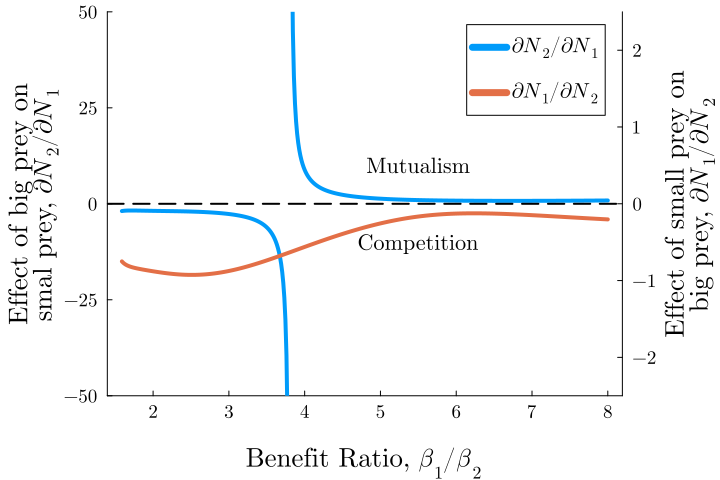

In [12]:
plt

# s = 3


[0.5160113414805136, 0.17307648668348283, 0.9021527194330379, 0.07736818586576776, 0.07170239769287202, 0.1313643891244365, 0.09112577637373924, 0.016308984067996475, 0.000873606178868358, 1.7467189493352224e-5, 1.580394628447542e-7, 7.565910531337158e-10][1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0][0.6594550278492795, 0.0, 0.01729774964045809, 0.0012230869467985167, 0.0035256138063680964, 0.014978491373974785, 0.04834495323101304, 0.08199508732117325, 0.0555745650666386, 0.014775320415013558, 0.0017026799004423296, 9.659061465571597e-5]

┌ Error: Failure to converge with given tolerance = 1.0e-12.
│ Step = 77
│ You can decrease the tolerance or pass a different norm using the argument `normC`.
│ We reached the smallest value [dsmin] valid for ds, namely 0.0001.
│ Stopping continuation at continuation step 77.
└ @ BifurcationKit /Users/taliaborofsky/.julia/packages/BifurcationKit/nhoqA/src/continuation/Contbase.jl:67


[0.0, 0.2642843959252067, 1.1576798533132275, 0.004466697797704581, 5.109706032403005e-6, 2.5436681732538846e-7, -3.026683353091379e-7, 2.528985573940073e-7, -1.449444073199522e-7, 5.454696041574495e-8, -1.2176386482481292e-8, 1.2253194533710525e-9][0.9990934107313862, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0][0.0, 0.9995805607141938, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

┌ Error: Failure to converge with given tolerance = 1.0e-12.
│ Step = 98
│ You can decrease the tolerance or pass a different norm using the argument `normC`.
│ We reached the smallest value [dsmin] valid for ds, namely 0.0001.
│ Stopping continuation at continuation step 98.
└ @ BifurcationKit /Users/taliaborofsky/.julia/packages/BifurcationKit/nhoqA/src/continuation/Contbase.jl:67


[-1.006090995500336, -0.1868702171870674, -0.2627264555505991, 0.16125510719843114, -0.00025967799523172953, 4.234334063279967e-7, -9.328487084899605e-10, 9.24977430675033e-12, -1.6822100458746849e-12, 2.9085439616930186e-12, -3.282735768364958e-11, 1.3737875610470673][-4.6315620392586935e-10, -0.05911510373384443, 0.3869094728892643, 0.17267638934410623, 0.1680561465920322, 0.1562646057468321, 0.13426448804393865, 0.10578485943953307, 0.07647489723301085, 0.05090450750895207, 0.031334750663495926, 0.01791711305508054][0.16567890291105322, -5.721927116150197e-9, 0.5478352635375466, 0.14444780090415493, 0.14812959280366805, 0.19126750274352788, 0.16406136336717944, 0.08196810344089243, 0.025513449107576264, 0.005384278483017832, 0.0008244911075932785, 9.642574440618032e-5]

...

[8.889817189612216e-29, -0.17855575765860998, 0.002072935463531447, 3.155469474940144e-6, 1.8616999961444855e-6, 2.193077416116308e-6, 4.141889377203167e-6, 1.169350935039495e-5, 4.958841082518396e-5, 0.0003419188587069611, 0.004916019984943721, 1.4556529655495691][2.8802936200708994e-27, -0.10083988136412762, 0.09460427602308209, 0.035748211462026544, 0.043169282062326196, 0.05974211688069545, 0.08504417468741833, 0.11914854331434559, 0.1610488335761251, 0.20808161864856567, 0.25594615339277665, 0.2992904540700504]

┌ Warning: continue_sp failed for N1_extinct specialpoint 2: ArgumentError("matrix contains Infs or NaNs")
└ @ CooperativeHuntingPkg.MyBifTools /Users/taliaborofsky/Documents/Postdoc/Collaborations/CH_GroupFormation/CH_code/Julia_version/CooperativeHuntingPkg/src/MyBifTools.jl:769


[1.0683979155280486e-27, -0.05911518575318299, 0.38690862191329034, 0.17267602821056327, 0.16805593439790464, 0.15626459248134944, 0.1342646622858295, 0.10578515723274447, 0.07647523585357233, 0.0509048186313326, 0.03133499667615332, 0.017917285675639816][5.528176963771809e-28, -0.045476172631725445, 0.5354135601251363, 0.22701828942107657, 0.18656523370167807, 0.13832183898853406, 0.0916011653505654, 0.054390417714721404, 0.02916420519688905, 0.014228052827965854, 0.0063600581283222695, 0.0026214778808742946][-5.002398096118379e-28, -9.508876778262513e-10, 0.9473777134301693, 0.22438113804060464, 0.07085789863135561, 0.016782299064418704, 0.0031798353376401365, 0.0005020842074396128, 6.795191525818344e-5, 8.047016580566055e-6, 8.470627193425576e-7, 8.024883748016692e-8]

┌ Error: Failure to converge with given tolerance = 1.0e-12.
│ Step = 45
│ You can decrease the tolerance or pass a different norm using the argument `normC`.
│ We reached the smallest value [dsmin] valid for ds, namely 0.0001.
│ Stopping continuation at continuation step 45.
└ @ BifurcationKit /Users/taliaborofsky/.julia/packages/BifurcationKit/nhoqA/src/continuation/Contbase.jl:67
┌ Warning: continue_sp failed for N1_extinct specialpoint 5: ErrorException("Newton failed to converge. Required for the computation of the initial tangent.")
└ @ CooperativeHuntingPkg.MyBifTools /Users/taliaborofsky/Documents/Postdoc/Collaborations/CH_GroupFormation/CH_code/Julia_version/CooperativeHuntingPkg/src/MyBifTools.jl:769
┌ Error: Failure to converge with given tolerance = 1.0e-12.
│ Step = 60
│ You can decrease the tolerance or pass a different norm using the argument `normC`.
│ We reached the smallest value [dsmin] valid for ds, namely 0.0001.
│ Stopping continuation at continuation step 60.
└ @

[-5.0e-324, 1.0000007808787663, -1.920339360998496e-6, -2.333800488556957e-9, -2.499139248907568e-12, -2.2485001279445907e-15, -1.7219315381082607e-18, -1.1427621106812967e-21, -6.67824586362165e-25, -3.482903946139047e-28, -1.6390949305655518e-31, -7.02504442919662e-35][1.000000000000678, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0][0.0, 1.000000000000031, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]hi

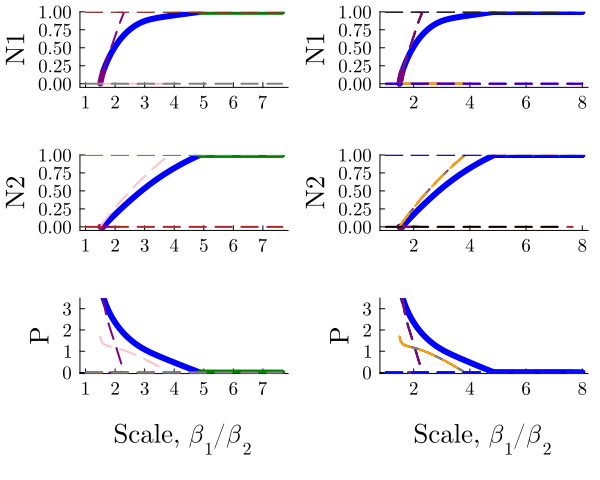

In [24]:
params_base = Dict(
    :α1_of_1 => 0.05,
    :α2_of_1 => 0.95,
    :s1 => 3.0,
    :s2 => 2.0,
    :H1a => 0.0,
    :H2a => 0.0,
    :H2b => 0.0,
    :A1 => 0.6,
    :A2 => 0.5,
    :η2 => 0.6,
    :β2 => 1.0,
    :α2_fun_type => "constant",
    :x_max => 10,
    :Tg => .01,
    :d => 100.0,
    :scale => 2.0
)
# type II, vary scale
params_t2 = deepcopy(params_base)
params_t2[:H1a] = params_t2[:H2a] = 0.0
params_t2[:H2b] = 1.0
p_nt = NamedTuple(scale_parameters(params_t2))


br_list, extra_branches = diagram_2_recursion(
    p_nt, paramkey = :scale; p_min = 1.01, p_max = 8.0, 
    lens = (@optic _.scale), systemfunction = fullsystem_scaled);
#plot_comparison_branches(br_list, extra_branches; ymax = 3.5)
plot_comparison_branches_filtered(br_list, [br_list...,extra_branches...], :scale; ymax = 3.5)

[0.5160113414805136, 0.17307648668348283, 0.9021527194330379, 0.07736818586576776, 0.07170239769287202, 0.1313643891244365, 0.09112577637373924, 0.016308984067996475, 0.000873606178868358, 1.7467189493352224e-5, 1.580394628447542e-7, 7.565910531337158e-10][1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0][0.6594550278492795, 0.0, 0.01729774964045809, 0.0012230869467985167, 0.0035256138063680964, 0.014978491373974785, 0.04834495323101304, 0.08199508732117325, 0.0555745650666386, 0.014775320415013558, 0.0017026799004423296, 9.659061465571597e-5]

┌ Error: Failure to converge with given tolerance = 1.0e-12.
│ Step = 77
│ You can decrease the tolerance or pass a different norm using the argument `normC`.
│ We reached the smallest value [dsmin] valid for ds, namely 0.0001.
│ Stopping continuation at continuation step 77.
└ @ BifurcationKit /Users/taliaborofsky/.julia/packages/BifurcationKit/nhoqA/src/continuation/Contbase.jl:67


[0.0, 0.2642843959252067, 1.1576798533132275, 0.004466697797704581, 5.109706032403005e-6, 2.5436681732538846e-7, -3.026683353091379e-7, 2.528985573940073e-7, -1.449444073199522e-7, 5.454696041574495e-8, -1.2176386482481292e-8, 1.2253194533710525e-9][0.9990934107313862, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0][0.0, 0.9995805607141938, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

┌ Error: Failure to converge with given tolerance = 1.0e-12.
│ Step = 98
│ You can decrease the tolerance or pass a different norm using the argument `normC`.
│ We reached the smallest value [dsmin] valid for ds, namely 0.0001.
│ Stopping continuation at continuation step 98.
└ @ BifurcationKit /Users/taliaborofsky/.julia/packages/BifurcationKit/nhoqA/src/continuation/Contbase.jl:67


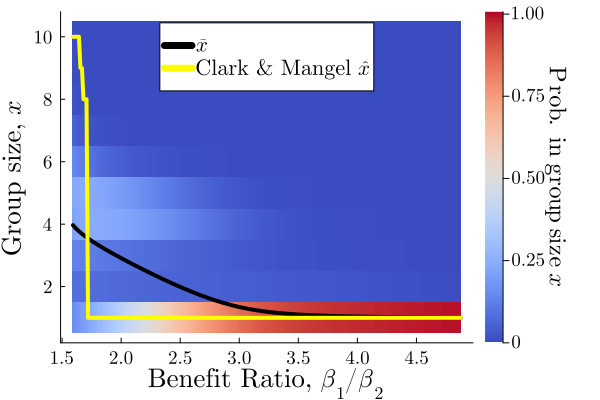

In [25]:

stable_coexist_t2, gmat_t2 = get_stable_equilibria(params_t2)
∂N2_∂N1_t2, ∂N1_∂N2_t2 = get_apparent_comp_bothways(stable_coexist_t2, gmat_t2, params_t2)




plt = plot(
    stable_coexist_t2[:param], 
    ∂N2_∂N1_t2, 
    label = L"\partial N_2/\partial N_1", 
    color = 1, 
    ylabel = "Effect of big prey on\n"*"smal prey, "*L"\partial N_2/\partial N_1",
    xlab = "\n"*param_label_dic[:scale],
    ylims = [-50,50]
    )
annotate!((5.5,10,"Facilitatation"))
annotate!((5.5,-10,"Competition"))

plot!([], [], color = :white, label = " ")
plot!([],[], color = 2,label = L"\partial N_1/\partial N_2")
plot!(
    twinx(), stable_coexist_t2[:param], ∂N1_∂N2_t2, 
    label = nothing,#[L"N_2 \to N_1"], 
    ylabel = "Effect of small prey on\n"*L"big prey, $\partial N_1/\partial N_2$",
    color = 2,
    ylims = [-2.5,2.5])
hline!([0], color = :black, linestyle = :dash, linewidth = 2, label = nothing)
plot!(
    legend = :topright,
    rightmargin=4mm,
    leftmargin=4mm,
    bottommargin = 3mm, # prevents xlab from being cutoff
    size=(720,480)
)

#savefig(plt, bif_fig_path*"apparent_comp_t2_scale.pdf")
plt

plt_heat = plot_distribution_heatmap(gmat_t2, stable_coexist_t2, params_t2[:x_max])
plot_mc_line(plt, stable_coexist_t2, params_t2)
plot!(legend=:top)
#savefig(plt_heat, bif_fig_path*"distribution_t2_scale.pdf")
plt_heat




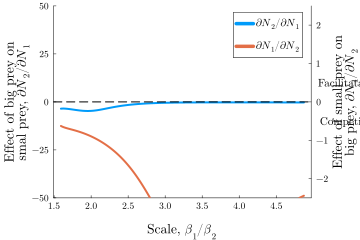

In [149]:
plot!(plt, dpi = 50)

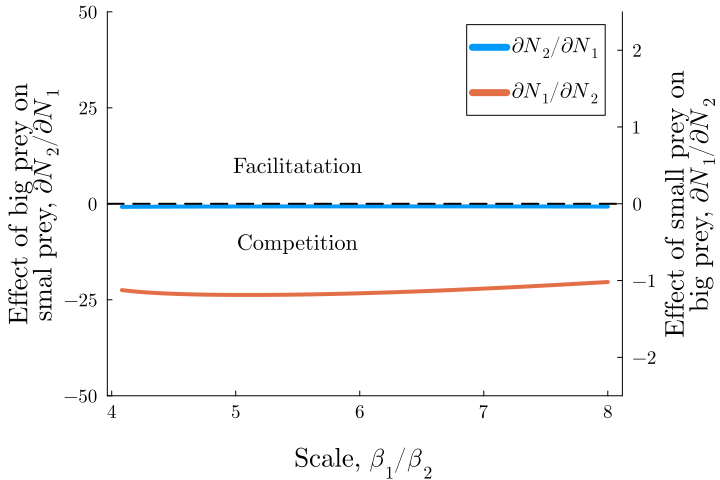

In [156]:
plt